12931635
landscape-jpeg, 2163587 data points


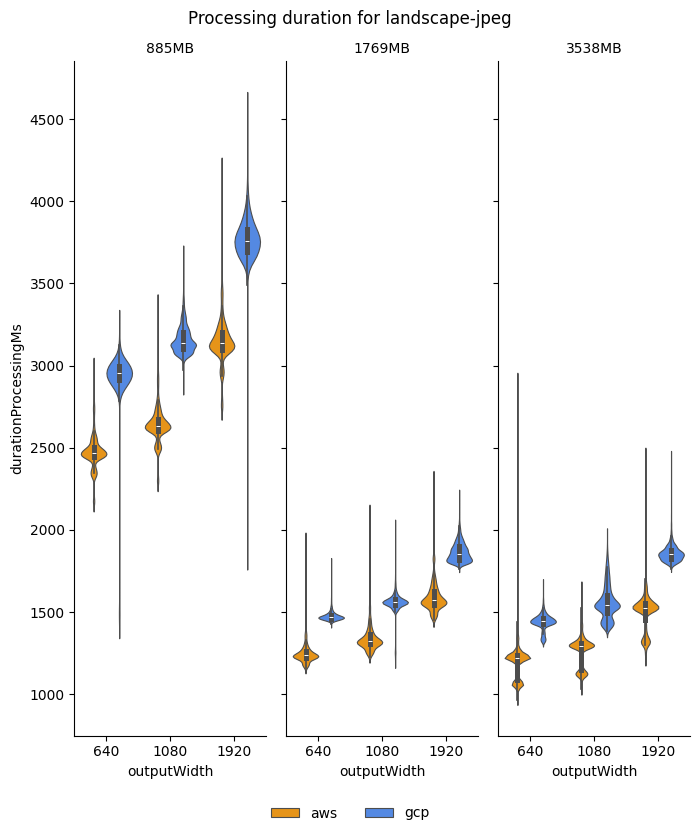

236463 data points


/var/folders/xz/hg1lcj4d4g19nhnbwzwj9hbw0000gr/T/ipykernel_16091/1261269791.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['time_of_day'] = data2['timestamp'].apply(lambda x: x % day)


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

pd.set_option('display.width', 1000)
palette = {'aws': '#ff9900', 'gcp': '#4285F4'}
df = pd.read_pickle('../stats-all-latest.pkl')
print(df.size)
# df = df.loc[(df["timestamp"] > 1733011200000+86400000*7)]

for imageName in ["landscape", "portrait"]:
    for outputFormat in ['jpeg', 'webp', 'heif']:
        data = df.loc[(df["imageName"] == imageName) & (df["outputFormat"] == outputFormat)]
        print(f"{imageName}-{outputFormat}, {data.size} data points")
        # if data.empty:
        #     print(f'No data for {imageName} {outputFormat}')
        #     continue

        ax = sns.catplot(
            kind='violin',
            x='outputWidth',
            y='durationProcessingMs',
            col='providerMemoryAssociated',
            # row='outputFormat',
            hue='providerName',
            data=data,
            height=8,
            aspect=0.25,
            sharex=False,
            # sharey='row',
            saturation=0.8,
            dodge=True,
            hue_order=['aws', 'gcp'],
            # row_order=['jpeg', 'webp', 'heif'],
            linewidth=0.8,
            density_norm='count',
            palette=palette,
        )
        # sns.move_legend(ax, "upper right", ncol=2)
        # sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 0.5))
        sns.move_legend(ax, loc='upper center', bbox_to_anchor=(0.5, 0), title=None, ncol=2)
        ax.set_titles("{col_name}MB")
        plt.suptitle(f'Processing duration for {imageName}-{outputFormat}')
        plt.tight_layout()
        ax.savefig(f'../graphs/4-daily-changes-{imageName}.pdf', bbox_inches='tight')
        plt.show()
        plt.close()

        # now do a seaborn chart with timestamp modulo beginning of a week as the x axis
        # data2 = data.loc[(data["providerMemoryAssociated"] == 885) & (data["providerName"] == "aws") & (data["timestamp"] > 1733011200000+86400000*14)]
        data2 = data.loc[(data["providerMemoryAssociated"] == 885) & (data["timestamp"] > 1733011200000+86400000*14)]
        print(f"{data2.size} data points")
        day = 86400000
        data2['time_of_day'] = data2['timestamp'].apply(lambda x: x % day)
        ax2 = sns.catplot(
            kind='strip',
            x='time_of_day',
            y='durationProcessingMs',
            col='outputWidth',
            # row='outputFormat',
            # style='outputWidth',
            hue='providerName',
            data=data2,
            size=2,
            # height=8,
            aspect=2.5,
            # sharex=False,
            # sharey='row',
            # saturation=0.8,
            dodge=True,
            hue_order=['aws', 'gcp'],
            # row_order=['jpeg', 'webp', 'heif'],
            # linewidth=0.8,
            # density_norm='count',
            palette=palette,
        )
        plt.suptitle(f'Processing duration for {imageName}-{outputFormat}-885')
        plt.show()



